## **Baseline Unimodal**

Para cada uno de los codificadores base seleccionados por cada modalidad, se definen y entrenan clasificadores independientes para el **corpus global**, empleando para ello hiperparámetros derivados del **EDA** y la literatura. Esto permite establecer una línea base para comparar la mejora o no de rendimiento de la fusión, y elegir en el siguiente *notebook* los extractores de características que mayores resultados alcanzan conjuntamente. 

**El notebook se estructura de la siguiente manera:**
1. **Definición de las Clases Unimodales (Dataset)**: En PyTorch, es necesario que, para la carga de datos (labels y embeddings), se debe crear una clase que herede de `torch.utils.data.Dataset`, que esta es la encargada de, indicando la ruta donde se encuentran estos datos, cargarlos debidamente y devolver el tensor (embedding) y la etiqueta (label) asociada a dicha muestra. Se define una clase por cada modalidad por separado para cargar los datos individualmente y que el posterior DataLoader devuelva los datos por cada modalidad específica. 
2. **Clasificador Unimodal**: Se crea el clasificador detallando la estructura (que debe ser similar a la estructura del clasificador definido tras aplicar las estrategias de fusión, y así permitir la comparación justa).
3. **Función de Entrenamiento**: Se crea la función encargada del entrenamiento del modelo unimodal, la cual primero instanciará el adaptador de la modalidad, llevará a cabo el entrenamiento iterando a nivel de *epoch*/*batch*, y tras cada *epoch*, evaluará en validación el rendimiento del modelo (*forward-pass*) controlando mediante *early-stopping* el sobreajuste.
4. **Bucle de Ejecución**: Celda de código central del notebook, ya que en ella se cargan los datos y se ejecuta el entrenamiento de los modelos unimodales.
5. **Función de Evaluación**: Esta función se encargará de evaluar con las métricas clave de nuestro proyecto, en la partición de validación, los modelos unimodales entrenados.
6. **Resultados de Evaluación**: Se muestra por cada modelo unimodal los resultados obtenidos y se analizan. 

In [2]:
# Importación de las librerías
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, recall_score
import copy
import numpy as np
import pandas as pd
from IPython.display import display
from torch.utils.data import Dataset
from tqdm import tqdm

from models.adapters import VisualAdapter, AudioAdapter, TextAdapter

# Configuración del dispositivo:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno de ejecución configurado en: {device}")

Entorno de ejecución configurado en: cuda


### **Clases Unimodales (Dataset) para la carga de datos**:

Para que PyTorch pueda leer los embeddings de cada una de las modalidades por cada codificador, debemos crear nuestras propias clases que deben heredar de torch.utils.data.Dataset, y debemos implementar los métodos `__len__` y `__getitem__`, además del constructor.

In [3]:
# CLASE para la carga de los datos de VÍDEO:

class VideoBaselineDataset(Dataset):
    def __init__(self, subject_ids, labels, base_dir, folder):
        self.subject_ids = subject_ids
        self.labels = labels
        self.base_dir = base_dir
        self.folder = folder
        self.max_frames = 32 # Fijamos 32 frames para los baselines unimodales de vídeo

    def __len__(self): 
        return len(self.subject_ids)

    def __getitem__(self, idx):
        """
        Extraemos los embeddings .npy obtenidos del codificador
        """
        path = os.path.join(self.base_dir, self.folder, f"{self.subject_ids[idx]}.npy")
        tensor = torch.tensor(np.load(path), dtype=torch.float32)

        return tensor, self.labels[idx]
    


# CLASE para la carga de los datos de AUDIO: 

class AudioBaselineDataset(Dataset):
    def __init__(self, subject_ids, labels, base_dir, folder, max_len):
        self.subject_ids = subject_ids
        self.labels = labels
        self.base_dir = base_dir
        self.folder = folder
        self.max_len = max_len # 350 pasos de tiempo equivalen a 11 segundos en el caso de MFCCs, en el caso de Wav2Vec 11s son 550 pasos. Lo fijamos así para el baseline unimodal de audio

    def __len__(self): 
        return len(self.subject_ids)

    def __getitem__(self, idx):
        """
        Extraemos los embeddings .npy obtenidos del codificador
        """
        path = os.path.join(self.base_dir, self.folder, f"{self.subject_ids[idx]}.npy")
        tensor = torch.tensor(np.load(path), dtype=torch.float32)
        sec_len = tensor.size(0)
        if sec_len > self.max_len: # Truncamos
            tensor = tensor[:self.max_len, :]
        elif sec_len < self.max_len: # Padding
            padding = torch.zeros(self.max_len - sec_len, tensor.size(1))
            tensor = torch.cat((tensor, padding), dim=0)
        return tensor, self.labels[idx]
    

# CLASE para la carga de los datos de Texto:

class TextBaselineDataset(Dataset):
    def __init__(self, subject_ids, labels, base_dir, folder):
        self.subject_ids = subject_ids
        self.labels = labels
        self.base_dir = base_dir
        self.folder = folder

    def __len__(self): 
        return len(self.subject_ids)

    def __getitem__(self, idx):
        """
        Extraemos los embeddings .npy obtenidos del codificador
        """
        path = os.path.join(self.base_dir, self.folder, f"{self.subject_ids[idx]}.npy")
        # El texto siempre extrae la posición 0 (el [CLS] token)
        tensor = torch.tensor(np.load(path)[0, :], dtype=torch.float32)
        return tensor, self.labels[idx]


### **Arquitectura Clasificador Unimodal**

Para una comparación justa con las posteriores estrategias de fusión, esta arquitectura cuenta con **2 partes**, imitando las arquitecturas multimodales que construiremos a continuación:

* **Adaptador**: Toma las representaciones densas (*embeddings*) del codificador base y las proyecta a un espacio latente común de 512 dimensiones (normalizado con media 0 y desviación 1). Esto también estará presente para las posteriores estrategias *early*, *late* y *attention fusion*. 

* **Clasificador MLP**: Se define un clasificador unimodal genérico constituido por dos capas lineales que comprimen la representación de 512 dimensiones inicial (que toma el adaptador correspondiente de la modalidad) a una única salida final en bruto (logit). Esta cuenta con capas de dropout y ReLU para evitar el sobreajuste y aplicar no linealidad, respectivamente. 

    * **Estructura**:
        - Capa Lineal(512, 128): Reducción de la dimensionalidad 512 -> 128,
        - ReLU(): Capa no lineal, establecemos a 0 los valores negativos,
        - Dropout(0.5): Evitamos sobreajuste,
        - Capa Lineal(128,1): Reducción de 128 a 1 (salida).
    Debido a la naturaleza desbalanceada del dataset, para una mayor robustez, se aplica la función de pérdida BCEWithLogitsLoss porque es más estable. Esto se mantendrá para las posteriores estrategias de fusión.

In [4]:
class UnimodalClassifier(nn.Module):
    """
    Clasificador unimodal genérico. 
    Toma el adaptador correspondiente a la modalidad (que proyecta a 512 dimensiones)
    y le añade capas lineales + BatchNorm + dropout + ReLU para la clasificación binaria (Estrés vs No Estrés)
    """
    def __init__(self, adapter):
        super(UnimodalClassifier, self).__init__()

        # 1. Adaptador
        self.adapter = adapter
        
        # 2. Clasificador MLP
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1) #Salida LOGIT
        )
        
    def forward(self, x):
        features = self.adapter(x)
        output = self.classifier(features)
        return output

### **Función de Entrenamiento**

**Hiperparámetros fijados**:

- **Configuración de la arquitectura**: Valores fijados teniendo en cuenta los valores respaldados por la literatura y las dimensiones de los vectores de entrada.

    * `proj_dim`= 512. Las dimensiones del espacio latente común de las modalidades será de 512.
    * `hidden_mlp`= 128. Este valor indica las dimensiones del espacio latente proyectado por la primera capa del Clasificador MLP, para comprimir las características iniciales recibidas. 
    * `hidden_lstm`= 512. Este valor indica las dimensiones del vector resultante obtenido de la última capa oculta de la LSTM. 
    * `lstm_layers`= 1. La LSTM de los adaptadores contará con 1 única capa.

- **Entrenamiento y Regularización**: Parámetros fijados de acuerdo a la literatura.

    * `lr` (**Learning Rate**)= 1e-4 (valor predeterminado)
    * `dropout`= 0.5 (valor predeterminado)
    * `weight_decay`= 1e-2 (valor predeterminado)
    * `epochs`= 20 (valor predeterminado)
    * `patience`= 5 (valor predeterminado)
    * `pos_weight_mult`= 1.0 (valor predeterminado). Este valor es el multiplicador para el peso de la clase positiva, a mayor valor hacemos que el modelo reciba mayor penalización cuando falla en la clase positiva (estrés).

- **Gestión del Desbalanceo**:
    - `BCEWithLogitsLoss` + `pos_weight`: Esta función de pérdida integra una capa Sigmoide junto con la pérdida de entropía cruzada binaria clásica (*Binary Cross-Entropy*). Gracias a ella, se permite introducir un parámetro de entrada (`pos_weight`) para aplicar una penalización extra cuando el modelo falla en la clase minoritaria (estrés). Para abordar este desbalanceo, gracias a `pos_weight`, se aplica una técnica llamada *Cost-Sensitive Learning*, donde se calcula este peso positivo como ratio entre el número de muestras negativas y positivas (**num_negativos/num_positivos**) fijado en train. Para validación y test aplicamos este mismo valor, y así evitamos la fuga de datos. Este parámetro es una constante global para las distintas particiones/modalidades/batches, toma un único valor constante calculado con train. Al incorporar este coeficiente a la función de pérdida, la red penaliza mucho más los errores de clasificación cometidos en la clase minoritaria. Esto es una práctica estándar en el tratamiento de datasets desbalanceados en Machine Learning. 

- **Regularización y Optimizador**:

    - `AdamW` con `weight_decay=1e-2`: Variante superior a `Adam` clásico, ya que `Adam` es mucho más propenso a sobreajuste para datasets medianos o pequeños (ya que *weight decay* no es independiente del gradiente). Según demuestran Loshchilov y Hutter en su trabajo *Decoupled Weight Decay Regularization*, `AdamW` desacopla el decaimiento de los pesos (*weight decay*) del cálculo de los gradientes adaptativos. Se fija un **weight_decay = 1e-2**, lo que introduce una penalización L2 que restringe el crecimiento excesivo de los pesos. Garantizamos así una mayor generalización del modelo. 

    - `Learning Rate`(**1e-4**): Estándar de oro en la literatura.

- **Ciclo de Entrenamiento**:

    - **Epochs** `20` y **Batch Size** `32`: Equilibrio entre estabilidad del gradiente y consumo de memoria. Fijamos pocas épocas ya que enfoques basados en *embeddings* preentrenados tienden a converger rápidamente. 

    - **Early Stopping (Paciencia = 5)**: Para evitar el sobreajuste, se implementa el mecanismo de parada temprana con una paciencia de 5 épocas. El criterio de monitorización no es la exactitud (*accuracy*) sino el **F1-Score Macro**, que es nuestra principal métrica debido al desbalanceo del dataset. 

- **Tamaño Ventanas**:

    - Fijamos las ventanas extraídas en las conclusiones del EDA:
        - **Video**: **32 frames**.
        - **Audio**: **11 segundos**.
        - **Texto**: **64 tokens**.

In [5]:
def train_unimodal(modalidad, backbone_name, train_loader, val_loader, train_labels, input_dim, epochs=20, patience=5):
    print(f"ENTRENAMIENTO BASELINE:\nModalidad: {modalidad.upper()}\nBackbone: {backbone_name.upper()}")
    
    # Instanciamos el adaptador correcto de acuerdo a la modalidad:
    if modalidad == 'video': 
        model = UnimodalClassifier(VisualAdapter(input_dim)).to(device)
    elif modalidad == 'audio': 
        model = UnimodalClassifier(AudioAdapter(input_dim)).to(device)
    elif modalidad == 'texto': 
        model = UnimodalClassifier(TextAdapter(input_dim)).to(device)
    
    # Cálculo de pos_weight para BCEWithLogitsLoss
    num_negativos = train_labels.count(0)
    num_positivos = train_labels.count(1)
    pos_weight_val = num_negativos / num_positivos if num_positivos > 0 else 1.0
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val], dtype=torch.float32).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    
    best_val_f1 = 0.0
    contador_paciencia = 0
    best_model_path = f"pesos_baseline_unimodal_{modalidad}_{backbone_name}.pth"
    
    
    for epoch in range(epochs):
        # -- TRAIN ---
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for inputs, labels in progress_bar:
            inputs = inputs.to(device)
            labels = labels.unsqueeze(1).float().to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
            
        train_loss = running_loss / len(train_loader)
            
        # -- VALIDACIÓN --
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels_tensor = labels.unsqueeze(1).float().to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels_tensor)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.numpy())
                
        val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1 Macro: {val_f1:.4f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            contador_paciencia = 0
        else: # Verificamos EARLY STOPPING
            contador_paciencia += 1
            if contador_paciencia >= patience:
                print(f"[EARLY STOPPING]")
                break
                
    print(f"\nFIN {modalidad.upper()} ({backbone_name}) | Mejor F1 Macro: {best_val_f1:.4f}\n")

### **Bucle de Ejecución**

In [6]:
#------------------------------------------------------------------
# LECTURA DE DATOS (en el servidor DGX)
# -----------------------------------------------------------------

BASE_DIR = os.path.expanduser('/workspace')
csv_path = os.path.join(BASE_DIR, 'Multimodal_Stress_Dataset.csv')

df = pd.read_csv(csv_path)

# Creamos una columna temporal llamada 'file_id' en df con el nombre exacto de los archivos .npy (sin la extensión)
# FORMATO: "Dialogue_ID_Utterance_ID" reemplanzando cualquier barra por guión bajo
df['file_id'] = (df['Dialogue_ID'].astype(str) + "_" + df['Utterance_ID'].astype(str)).str.replace("/", "_")

# FILTRAMOS los datos de TRAIN (Columna 'split' == 'train') y los de Validación ('dev'):
df_train = df[df['split']=='train']
train_ids = df_train['file_id'].tolist()
train_labels = df_train['target_stress'].tolist()

df_val = df[df['split']=='dev']
val_ids = df_val['file_id'].tolist()
val_labels = df_val['target_stress'].tolist()


# BACKBONES de cada modalidad: 
backbones_video = {
    'resnet': 'features_resnet',
    'vit': 'features_vit',
    'efficientnet': 'features_efficientnet'
}

backbones_audio = {
    'wav2vec': 'features_audio_COMPLETO/audio_wav2vec',
    'mfcc': 'features_audio_COMPLETO/audio_handcrafted'
}

backbones_texto = {
    'roberta64': 'EMBEDDINGS_TEXT_ROBERTA_64',
    'bert64': 'EMBEDDINGS_TEXT_BERT_64',
    'deberta64': 'EMBEDDINGS_TEXT_DEBERTA_64'
}


def ejecutar_experimentos_unimodales():
    
    # --- VÍDEO ---
    for nombre, carpeta in backbones_video.items():
        if nombre == 'resnet':
            input_dim = 2048
        elif nombre == 'vit':
            input_dim = 768  
        elif nombre == 'efficientnet':
            input_dim = 1280
            
        # CARGA DE LOS DATOS (EMBEDDINGS):
        train_dataset = VideoBaselineDataset(train_ids, 
                                             train_labels, 
                                             BASE_DIR, 
                                             carpeta)
        val_dataset = VideoBaselineDataset(val_ids, 
                                           val_labels, 
                                           BASE_DIR, 
                                           carpeta)
        # CREAMOS EL DATALOADER: Este directamente devolverá --> (inputs, labels) para dicha modalidad
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        # ENTRENAMIENTO:
        train_unimodal('video', nombre, train_loader, val_loader, train_labels, input_dim=input_dim)


    
    # --- AUDIO ---
    for nombre, carpeta in backbones_audio.items():
        if nombre == 'mfcc':
            max_len = 350
            input_dim = 15
        else :
            max_len = 550
            input_dim = 768
        train_dataset = AudioBaselineDataset(train_ids, 
                                        train_labels, 
                                        BASE_DIR, 
                                        carpeta,
                                        max_len)
        val_dataset = AudioBaselineDataset(val_ids, 
                                      val_labels, 
                                      BASE_DIR, 
                                      carpeta,
                                      max_len)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        # ENTRENAMIENTO:
        train_unimodal('audio', nombre, train_loader, val_loader, train_labels, input_dim=input_dim)


    
    # --- TEXTO ---
    for nombre, carpeta in backbones_texto.items():
        input_dim = 768
        train_dataset = TextBaselineDataset(train_ids, 
                                       train_labels, 
                                       BASE_DIR, 
                                       carpeta)
        val_dataset = TextBaselineDataset(val_ids, 
                                     val_labels, 
                                     BASE_DIR, 
                                     carpeta)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        # ENTRENAMIENTO
        train_unimodal('texto', nombre, train_loader, val_loader, train_labels, input_dim=input_dim)




ejecutar_experimentos_unimodales()

ENTRENAMIENTO BASELINE:
Modalidad: VIDEO
Backbone: RESNET


Epoch 1/20: 100%|██████████████████████████████████████████████████████| 448/448 [00:08<00:00, 54.21it/s, loss=0.656]


Train Loss: 1.0437 | Val Loss: 1.1952 | Val F1 Macro: 0.6343


Epoch 2/20: 100%|███████████████████████████████████████████████████████| 448/448 [00:04<00:00, 96.53it/s, loss=0.85]


Train Loss: 0.9976 | Val Loss: 1.1910 | Val F1 Macro: 0.6484


...

Train Loss: 0.9703 | Val Loss: 1.3122 | Val F1 Macro: 0.6036


Epoch 11/20: 100%|█████████████████████████████████████████████████████| 448/448 [00:02<00:00, 207.70it/s, loss=1.25]


Train Loss: 0.9549 | Val Loss: 1.3086 | Val F1 Macro: 0.6065


Epoch 12/20: 100%|█████████████████████████████████████████████████████| 448/448 [00:02<00:00, 215.60it/s, loss=1.12]


Train Loss: 0.9471 | Val Loss: 1.3230 | Val F1 Macro: 0.5996
[EARLY STOPPING]

FIN TEXTO (deberta64) | Mejor F1 Macro: 0.6077



### **Evaluación Baselines Unimodales** (Validación)

In [7]:
def evaluar_unimodal(modalidad, backbone_name, model, val_loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader):
            inputs = inputs.to(device)
            # Obtenemos los logits: 
            outputs = model(inputs)
            # Pasamos a probabilidades para la curva ROC:
            probs = torch.sigmoid(outputs)
            # Obtenemos las predicciones aplicando el umbral de 0.5
            preds = (probs > 0.5).float()
            
            all_labels.extend(labels.cpu().numpy().flatten().tolist())
            all_preds.extend(preds.cpu().numpy().flatten().tolist())
            all_probs.extend(probs.cpu().numpy().flatten().tolist())

    # CÁLCULO DE MÉTRICAS (accuracy, F1-Score Macro, F1-Score Weighted, AUC, recall)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    auc = roc_auc_score(all_labels, all_probs)
    recall_estres = recall_score(all_labels, all_preds, pos_label=1)

    print(f"MÉTRICAS PARA EL CODIFICADOR EN {modalidad.upper()} ({backbone_name}) en VALIDACIÓN:")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"Accuracy (en %): {acc*100:.2f}%")
    print(f"Recall (Estrés): {recall_estres:.4f}")

    # MATRIZ DE CONFUSIÓN:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Estrés', 'Estrés'], yticklabels=['No Estrés', 'Estrés'])
    plt.title(f'Matriz de Confusión - {modalidad.upper()} ({backbone_name})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.savefig(f'Fig_matriz_confusion_baseline_unimodal_{modalidad.upper()}_{backbone_name}.png')
    plt.show()

    # CURVA ROC:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.savefig(f'Fig_curva_roc_baseline_unimodal_{modalidad.upper()}_{backbone_name}.png')
    plt.show()
    

    with open(f"reporte_final_baseline_unimodal_{modalidad.upper()}_{backbone_name}.txt", "w") as f:
        f.write(f"CODIFICADOR: {backbone_name}\n")
        f.write(f"ROC-AUC: {auc:.4f}\n")
        f.write(classification_report(all_labels, all_preds, target_names=['No Estrés', 'Estrés'], digits=4))

### **Resultados Baselines Unimodales** (Validación)

* **CODIFICADORES VISUALES** (Ventanas fijadas de 32 *frames*):
* `ResNet50`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 119.91it/s]


MÉTRICAS PARA EL CODIFICADOR EN VIDEO (resnet) en VALIDACIÓN:
ROC-AUC Score: 0.7347
F1 Macro: 0.6510
F1 Weighted: 0.6535
Accuracy (en %): 65.13%
Recall (Estrés): 0.8161


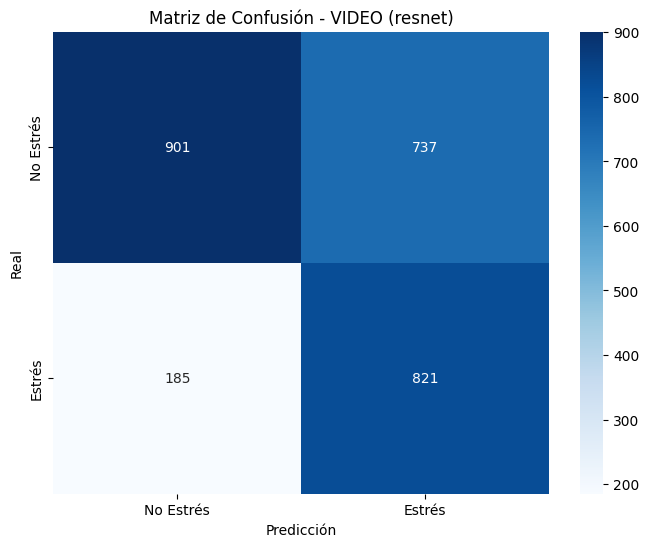

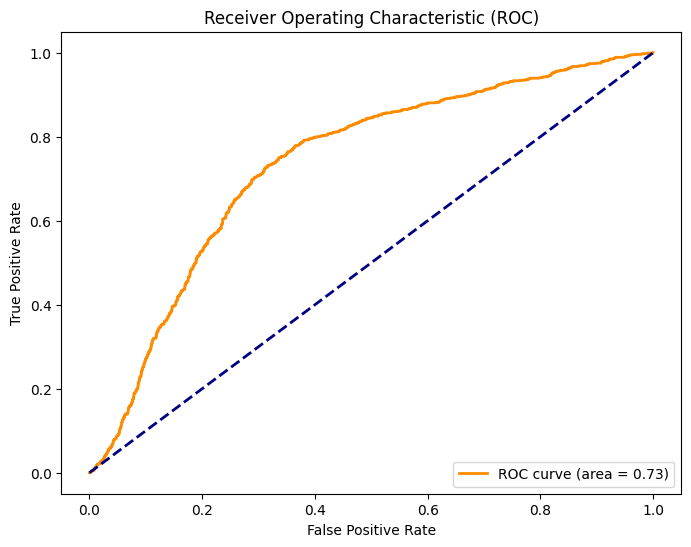

In [8]:
val_dataset = VideoBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_video['resnet'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(VisualAdapter(input_dim=2048)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_video_resnet.pth"))
evaluar_unimodal('video', 'resnet', model_eval, val_loader)

* `EfficientNet-B0`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 175.41it/s]


MÉTRICAS PARA EL CODIFICADOR EN VIDEO (efficientnet) en VALIDACIÓN:
ROC-AUC Score: 0.6897
F1 Macro: 0.6286
F1 Weighted: 0.6290
Accuracy (en %): 62.86%
Recall (Estrés): 0.8201


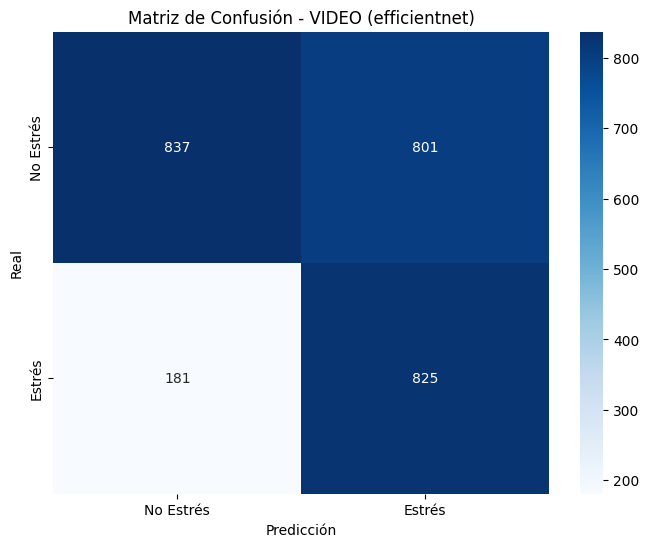

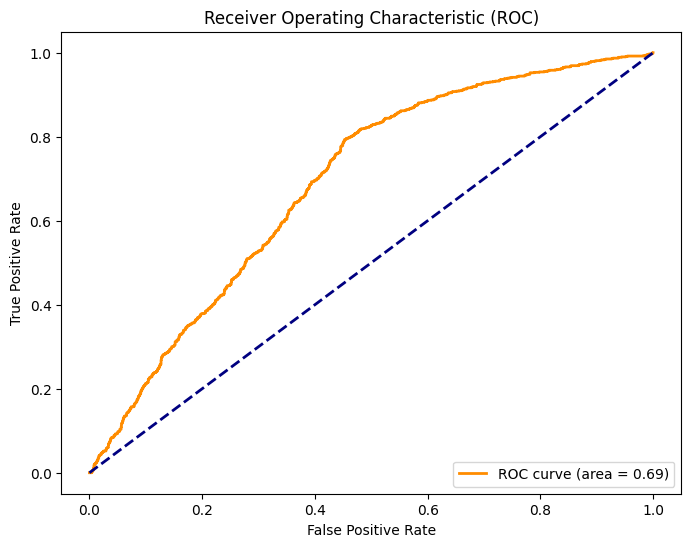

In [9]:
val_dataset = VideoBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_video['efficientnet'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(VisualAdapter(input_dim=1280)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_video_efficientnet.pth"))
evaluar_unimodal('video', 'efficientnet', model_eval, val_loader)

* `ViT`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 322.59it/s]


MÉTRICAS PARA EL CODIFICADOR EN VIDEO (vit) en VALIDACIÓN:
ROC-AUC Score: 0.7070
F1 Macro: 0.6485
F1 Weighted: 0.6503
Accuracy (en %): 64.86%
Recall (Estrés): 0.8231


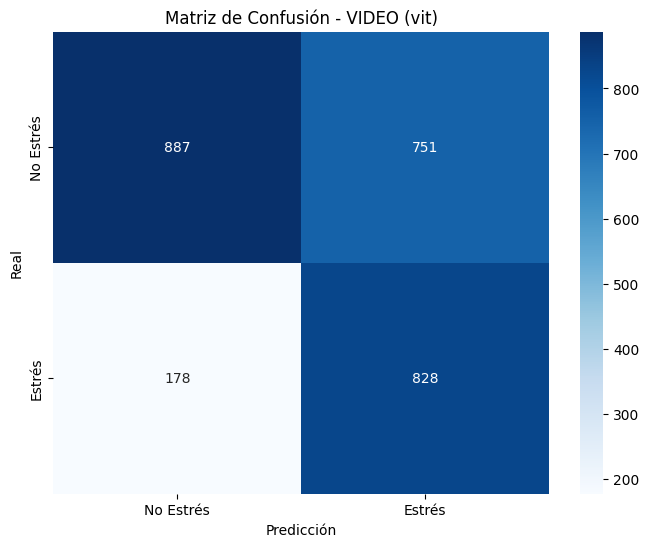

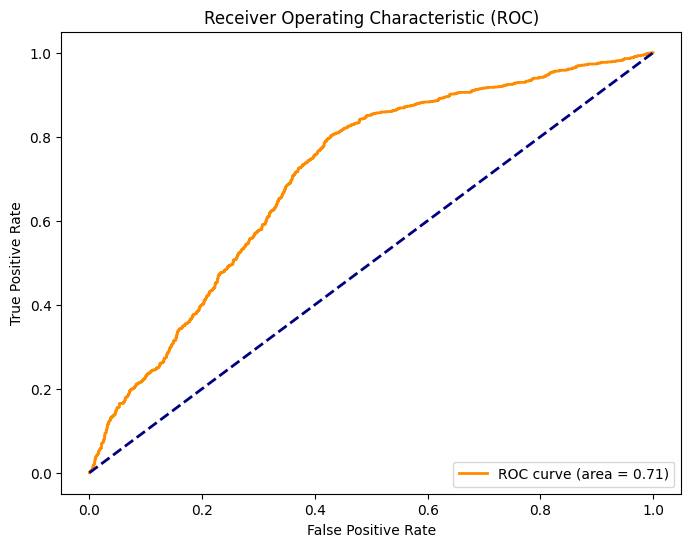

In [10]:
val_dataset = VideoBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_video['vit'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(VisualAdapter(input_dim=768)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_video_vit.pth"))
evaluar_unimodal('video', 'vit', model_eval, val_loader)

* **CODIFICADORES ACÚSTICOS** (Ventanas fijadas de 11s):

* `Wav2Vec 2.0`

100%|████████████████████████████████████████████████████████████████████████████████| 83/83 [00:02<00:00, 28.68it/s]


MÉTRICAS PARA EL CODIFICADOR EN AUDIO (wav2vec) en VALIDACIÓN:
ROC-AUC Score: 0.5470
F1 Macro: 0.4119
F1 Weighted: 0.4942
Accuracy (en %): 61.35%
Recall (Estrés): 0.0368


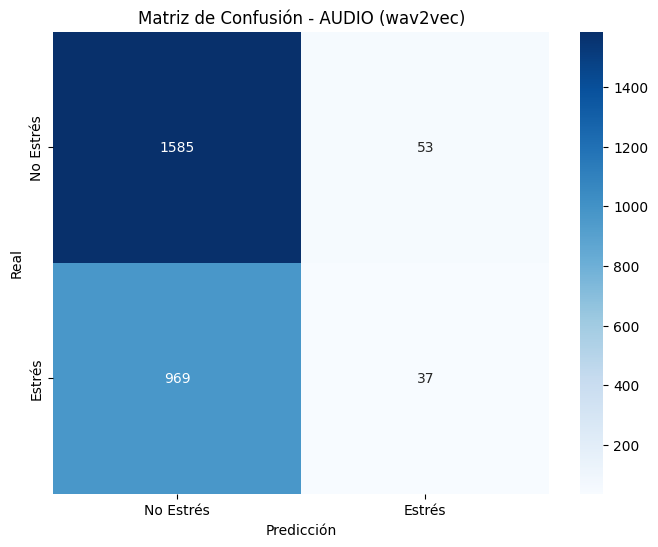

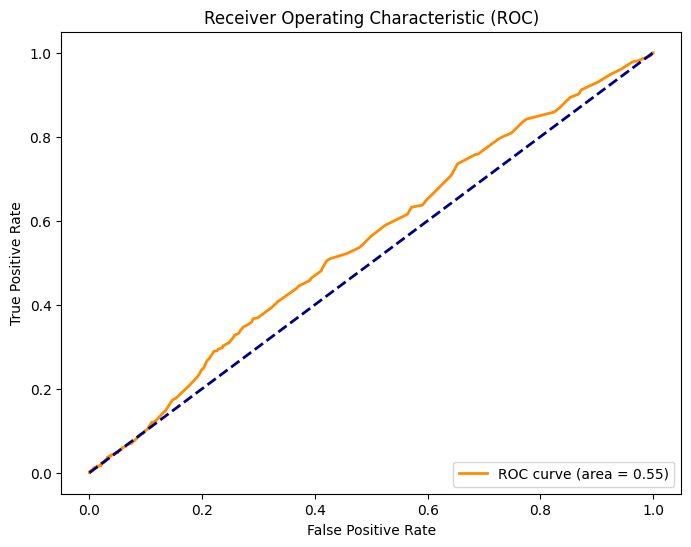

In [11]:
val_dataset = AudioBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_audio['wav2vec'], max_len=550)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(AudioAdapter(input_dim=768)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_audio_wav2vec.pth"))
evaluar_unimodal('audio', 'wav2vec', model_eval, val_loader)

* `MFCCs + RMS + ZCR`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 113.65it/s]


MÉTRICAS PARA EL CODIFICADOR EN AUDIO (mfcc) en VALIDACIÓN:
ROC-AUC Score: 0.5873
F1 Macro: 0.5497
F1 Weighted: 0.5603
Accuracy (en %): 55.41%
Recall (Estrés): 0.5984


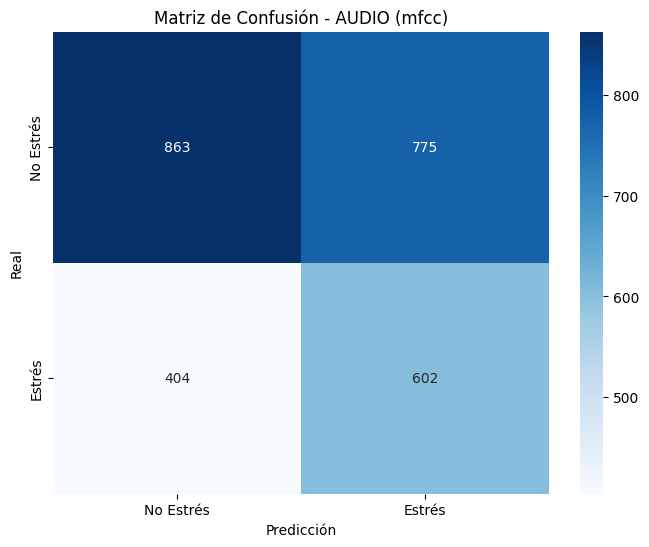

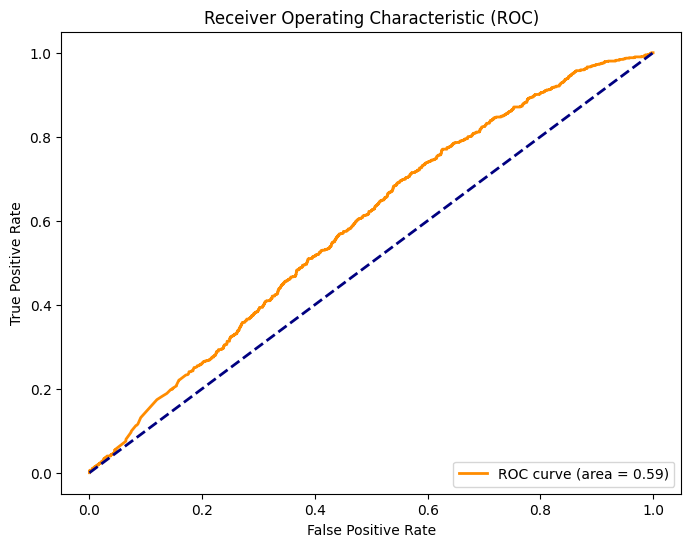

In [12]:
val_dataset = AudioBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_audio['mfcc'], max_len = 350)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(AudioAdapter(input_dim=15)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_audio_mfcc.pth"))
evaluar_unimodal('audio', 'mfcc', model_eval, val_loader)

* **CODIFICADORES TEXTUALES** (Ventanas fijadas de 64 tokens):
* `BERT`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 283.56it/s]


MÉTRICAS PARA EL CODIFICADOR EN TEXTO (bert64) en VALIDACIÓN:
ROC-AUC Score: 0.8197
F1 Macro: 0.7424
F1 Weighted: 0.7568
Accuracy (en %): 75.64%
Recall (Estrés): 0.6879


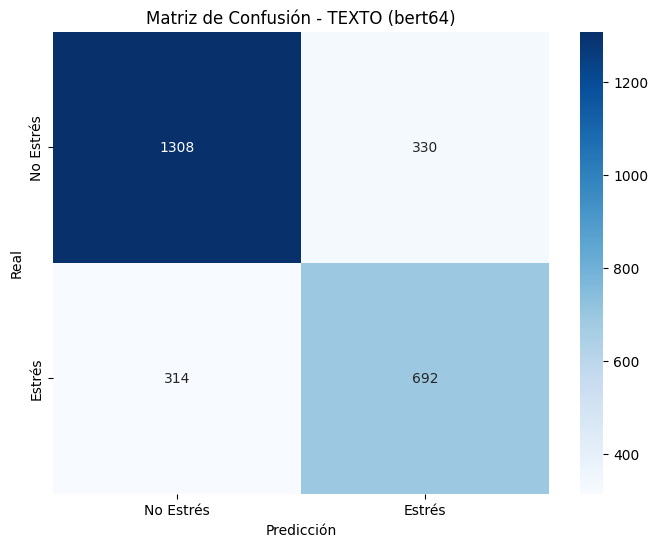

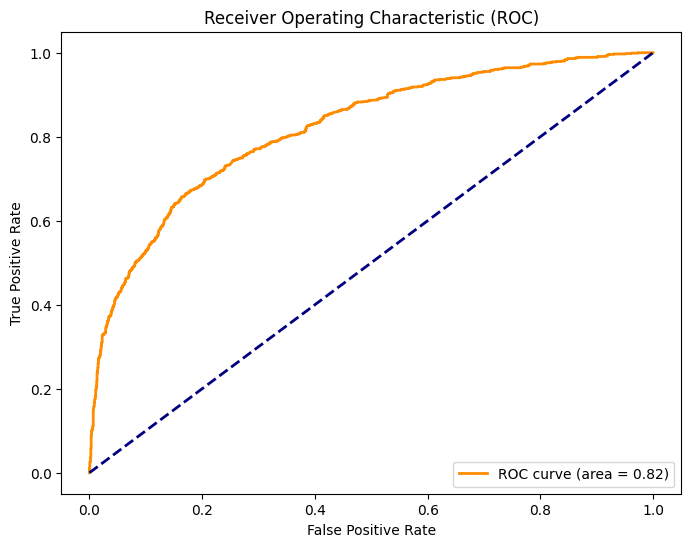

In [13]:
val_dataset = TextBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_texto['bert64'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(TextAdapter(input_dim=768)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_texto_bert64.pth"))
evaluar_unimodal('texto', 'bert64', model_eval, val_loader)

* `RoBERTa`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 205.23it/s]


MÉTRICAS PARA EL CODIFICADOR EN TEXTO (roberta64) en VALIDACIÓN:
ROC-AUC Score: 0.8070
F1 Macro: 0.7293
F1 Weighted: 0.7429
Accuracy (en %): 74.13%
Recall (Estrés): 0.6978


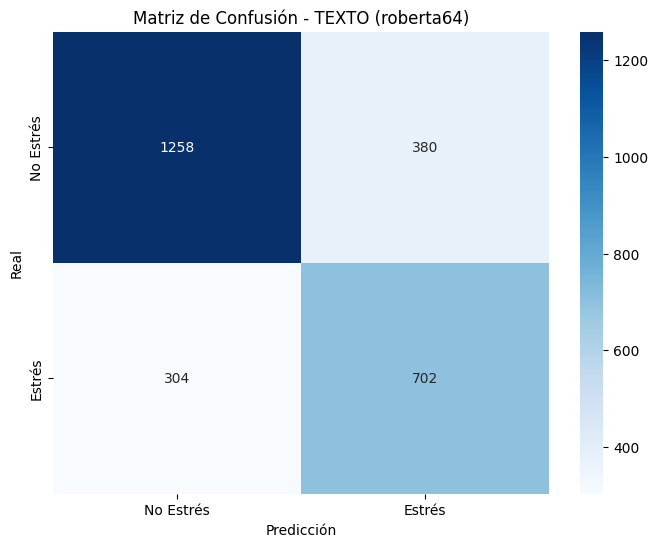

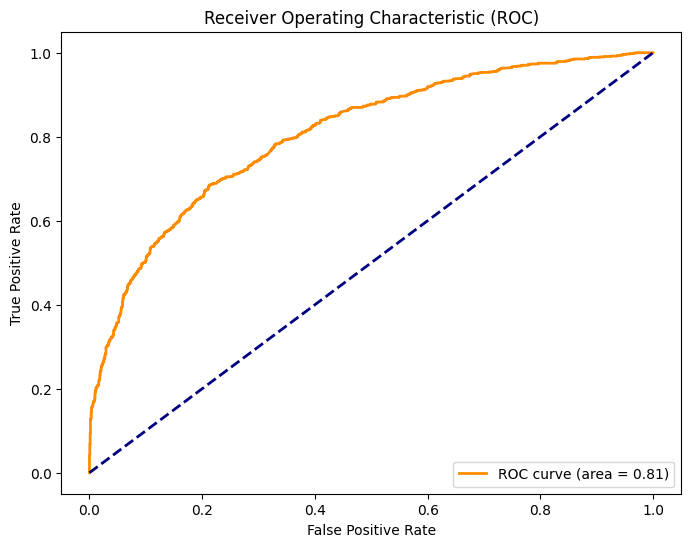

In [14]:
val_dataset = TextBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_texto['roberta64'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(TextAdapter(input_dim=768)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_texto_roberta64.pth"))
evaluar_unimodal('texto', 'roberta64', model_eval, val_loader)

* `DeBERTa`

100%|███████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 277.78it/s]


MÉTRICAS PARA EL CODIFICADOR EN TEXTO (deberta64) en VALIDACIÓN:
ROC-AUC Score: 0.6756
F1 Macro: 0.6077
F1 Weighted: 0.6191
Accuracy (en %): 61.35%
Recall (Estrés): 0.6471


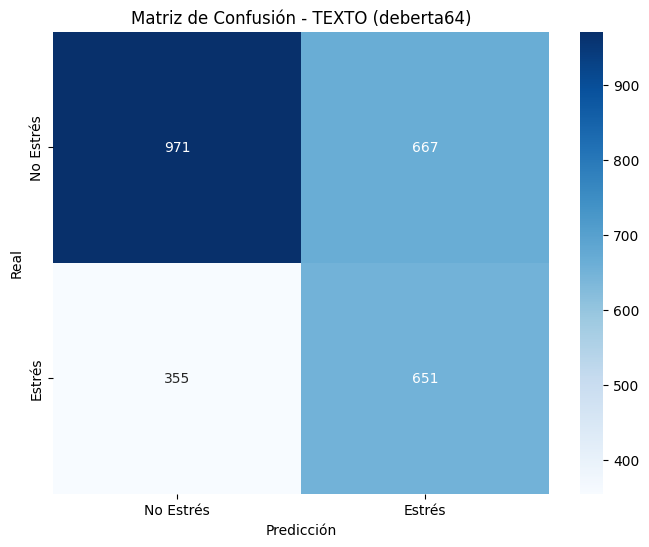

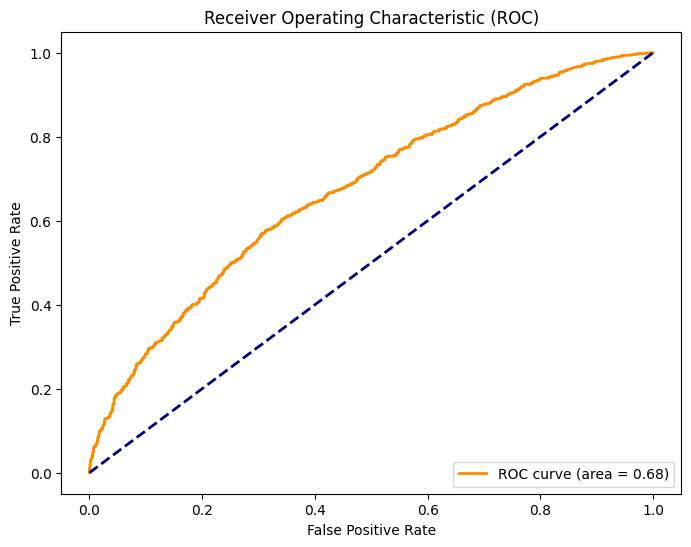

In [15]:
val_dataset = TextBaselineDataset(val_ids, val_labels, BASE_DIR, backbones_texto['deberta64'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model_eval = UnimodalClassifier(TextAdapter(input_dim=768)).to(device)
model_eval.load_state_dict(torch.load(f"pesos_baseline_unimodal_texto_deberta64.pth"))
evaluar_unimodal('texto', 'deberta64', model_eval, val_loader)

**Tabla comparativa con los resultados en validación de los 8 *baselines* unimodales**:

En la tabla se reflejan las 3 métricas principales (**F1-Score Macro**, **ROC-AUC**, **Recall (estrés)**) para cada uno de los modelos:

In [18]:
def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, el ROC-AUC y el Recall de la clase 'Estrés'.
    """
    f1_macro = 0.0
    auc = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, auc, recall_estres

In [21]:
# Definimos los 8 modelos base, su modalidad, ventana y la ruta de su txt:
rutas_baselines = [
    # VÍDEO (32 frames)
    {'Modelo': 'ResNet-50', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_VIDEO_resnet.txt'},
    {'Modelo': 'ViT', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_VIDEO_vit.txt'},
    {'Modelo': 'EfficientNet', 'Modalidad': 'Vídeo', 'Ventana': '32 frames', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_VIDEO_efficientnet.txt'},
    
    # AUDIO (11 segundos)
    {'Modelo': 'Wav2Vec 2.0', 'Modalidad': 'Audio', 'Ventana': '11 seg', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_AUDIO_wav2vec.txt'},
    {'Modelo': 'MFCCs (+ RMS + ZCR)', 'Modalidad': 'Audio', 'Ventana': '11 seg', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_AUDIO_mfcc.txt'},
    
    # TEXTO (64 tokens)
    {'Modelo': 'RoBERTa', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_TEXTO_roberta64.txt'},
    {'Modelo': 'BERT', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_TEXTO_bert64.txt'},
    {'Modelo': 'DeBERTa', 'Modalidad': 'Texto', 'Ventana': '64 tokens', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_TEXTO_deberta64.txt'}
]

datos_baselines = []
for item in rutas_baselines:
    f1, auc, recall = extraer_metricas_txt(item['Ruta'])
    datos_baselines.append({
        'Modalidad': item['Modalidad'],
        'Modelo': item['Modelo'],
        'Ventana': item['Ventana'],
        'F1_Macro': f1,
        'AUC': auc,
        'Recall_Estres': recall
    })

# Creamos el DataFrame y lo ordenamos por Modalidad y luego por F1:
df_baselines = pd.DataFrame(datos_baselines).sort_values(by=['Modalidad', 'F1_Macro'], ascending=[False, False])

# Lo guardamos como CSV:
df_baselines.to_csv("tabla_baselines_unimodales.csv", index=False)

# Mostramos en pantalla
print("TABLA: BASELINES UNIMODALES")
display(df_baselines.style.background_gradient(subset=['F1_Macro', 'AUC', 'Recall_Estres'], cmap='Blues').format(precision=4))

TABLA: BASELINES UNIMODALES


,Modalidad,Modelo,Ventana,F1_Macro,AUC,Recall_Estres
0,Vídeo,ResNet-50,32 frames,0.6510,0.7347,0.8161
1,Vídeo,ViT,32 frames,0.6485,0.7070,0.8231
2,Vídeo,EfficientNet,32 frames,0.6286,0.6897,0.8201
6,Texto,BERT,64 tokens,0.7424,0.8197,0.6879
5,Texto,RoBERTa,64 tokens,0.7293,0.8070,0.6978
7,Texto,DeBERTa,64 tokens,0.6077,0.6756,0.6471
4,Audio,MFCCs (+ RMS + ZCR),11 seg,0.5497,0.5873,0.5984
3,Audio,Wav2Vec 2.0,11 seg,0.4119,0.5470,0.0368
